# Full Analysis on Monthly Aggregated Data

This notebook performs the entire Gibbs sampling methodology, including Exploratory Data Analysis (EDA), MCMC Convergence Diagnostics, Regime Inference, and Structural Interpretation, entirely on **Monthly Aggregated** log-returns of the S&P 500 and NIFTY 50.

Following the methodology, we recalibrate the transition prior to `Beta(10, 2)` to encode the empirical regularity that financial regimes measured in months exhibit stronger persistence than weekly regimes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, invgamma, beta as beta_dist
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# Load Weekly Data
sp500_df = pd.read_csv('../data/sp500_data.csv', index_col='Date', parse_dates=True)
nifty50_df = pd.read_csv('../data/nifty50_data.csv', index_col='Date', parse_dates=True)
recession_df = pd.read_csv('../data/us_recession.csv', index_col='observation_date', parse_dates=True)

# Fix timezone issues
sp500_df.index = pd.to_datetime(sp500_df.index, utc=True).tz_localize(None)
nifty50_df.index = pd.to_datetime(nifty50_df.index, utc=True).tz_localize(None)
recession_df.index = pd.to_datetime(recession_df.index).tz_localize(None)

# Aggregate to Monthly
sp500_m = sp500_df.resample('ME').agg({'Close': 'last'})
sp500_m['Log_Return'] = np.log(sp500_m['Close'] / sp500_m['Close'].shift(1))
sp500_m = sp500_m.dropna()

nifty50_m = nifty50_df.resample('ME').agg({'Close': 'last'})
nifty50_m['Log_Return'] = np.log(nifty50_m['Close'] / nifty50_m['Close'].shift(1))
nifty50_m = nifty50_m.dropna()

print(f"S&P 500 monthly obs: {len(sp500_m)}")
print(f"NIFTY 50 monthly obs: {len(nifty50_m)}")


S&P 500 monthly obs: 255
NIFTY 50 monthly obs: 223


## 1. Exploratory Data Analysis (EDA) on Monthly Data
We visualize the monthly prices, log-returns, and their distributions to justify the multi-regime model.


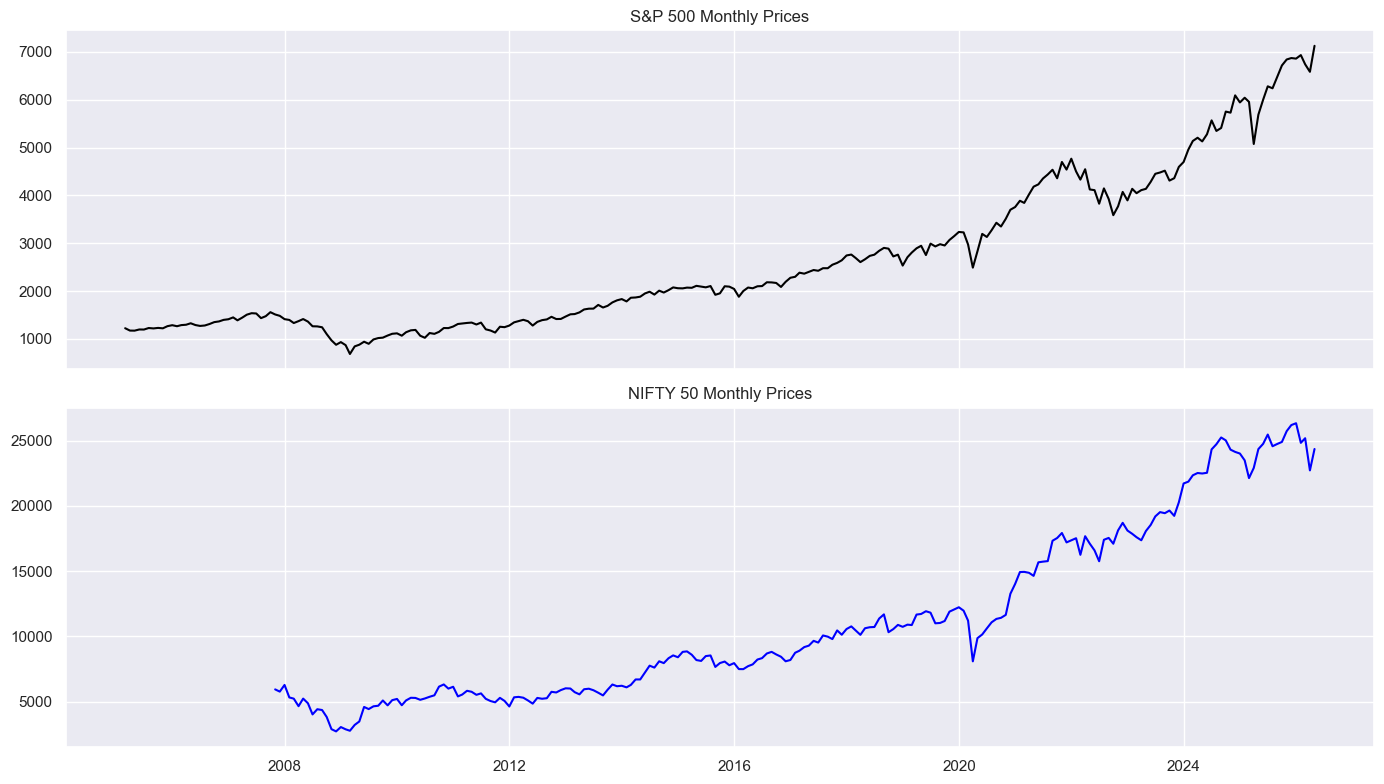

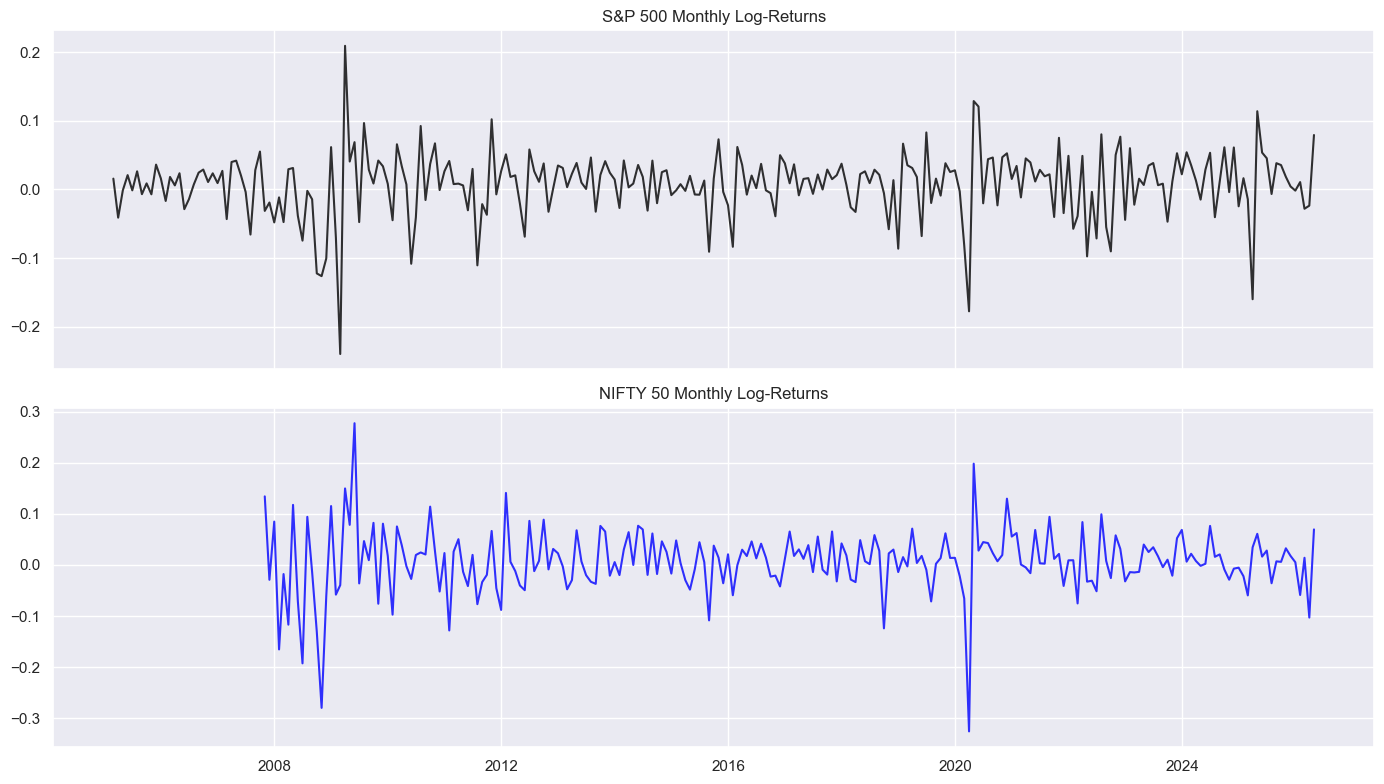

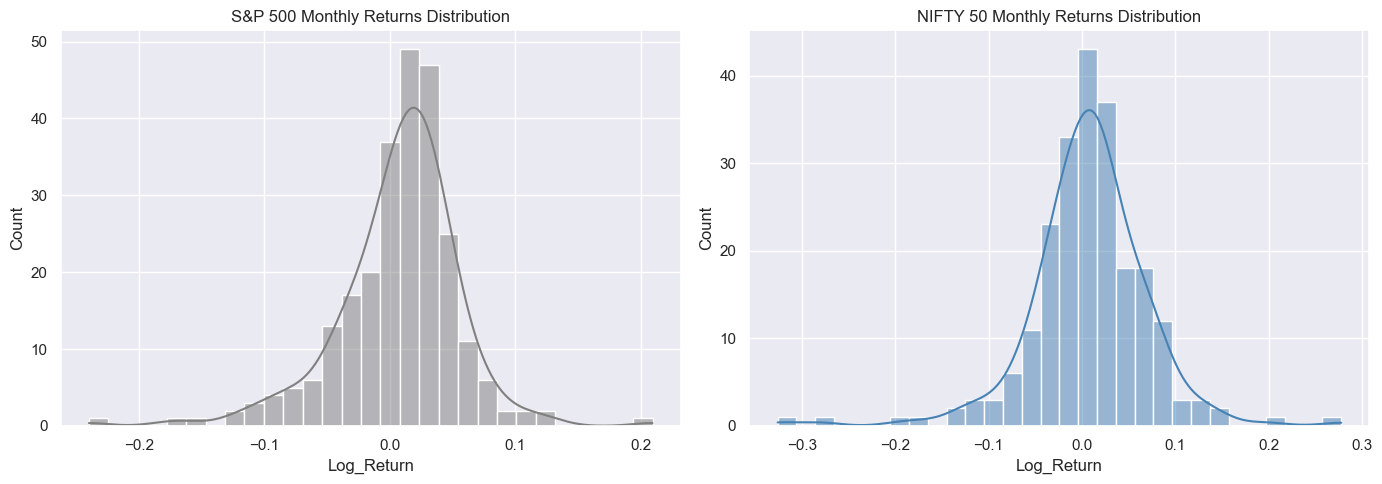

In [2]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(sp500_m.index, sp500_m['Close'], color='black')
ax[0].set_title('S&P 500 Monthly Prices')
ax[1].plot(nifty50_m.index, nifty50_m['Close'], color='blue')
ax[1].set_title('NIFTY 50 Monthly Prices')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(sp500_m.index, sp500_m['Log_Return'], color='black', alpha=0.8)
ax[0].set_title('S&P 500 Monthly Log-Returns')
ax[1].plot(nifty50_m.index, nifty50_m['Log_Return'], color='blue', alpha=0.8)
ax[1].set_title('NIFTY 50 Monthly Log-Returns')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sp500_m['Log_Return'], kde=True, ax=axes[0], color='gray')
axes[0].set_title('S&P 500 Monthly Returns Distribution')
sns.histplot(nifty50_m['Log_Return'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('NIFTY 50 Monthly Returns Distribution')
plt.tight_layout()
plt.show()


In [3]:
def ffbs(y, mu, sig2, p_diag):
    T = len(y)
    P_mat = np.array([[p_diag[0], 1 - p_diag[0]],
                      [1 - p_diag[1], p_diag[1]]])
    P_filt = np.zeros((T, 2))
    P_filt[0] = [0.5, 0.5]
    
    # Forward Pass (Filtered Probabilities)
    for t in range(1, T):
        P_pred = P_mat.T @ P_filt[t - 1]
        L = np.array([norm.pdf(y[t], loc=mu[j], scale=np.sqrt(sig2[j])) for j in range(2)])
        raw = P_pred * L
        s = raw.sum()
        P_filt[t] = raw / s if s > 0 else np.array([0.5, 0.5])
        
    # Backward Pass (Smoothed State Draw)
    S = np.zeros(T, dtype=int)
    S[-1] = np.random.choice(2, p=P_filt[-1])
    for t in range(T - 2, -1, -1):
        p_back = P_filt[t] * P_mat[:, S[t + 1]]
        s = p_back.sum()
        p_back = p_back / s if s > 0 else np.array([0.5, 0.5])
        S[t] = np.random.choice(2, p=p_back)
        
    return S, P_filt

def gibbs_msm(y, n_iter=2500, burn_in=500, a0=10.0, b0=2.0):
    T = len(y)
    med = np.median(y)
    mu = np.array([y[y < med].mean(), y[y >= med].mean()])
    sig2 = np.array([y.var(), y.var()])
    p_diag = np.array([0.95, 0.95])
    
    samples = {'mu': [], 'sigma2': [], 'p': [], 'P_filt': []}
    
    for k in range(n_iter):
        S, P_filt = ffbs(y, mu, sig2, p_diag)
        
        for j in range(2):
            idx = (S == j)
            n_j = idx.sum()
            if n_j > 0:
                prec = 1.0 + n_j / sig2[j]
                post_mu = (y[idx].sum() / sig2[j]) / prec
                mu[j] = np.random.normal(post_mu, 1.0 / np.sqrt(prec))
                
                a = 2.0 + n_j / 2.0
                b = 0.01 + 0.5 * ((y[idx] - mu[j]) ** 2).sum()
                sig2[j] = invgamma.rvs(a, scale=b)
                
            n_jj = ((S[:-1] == j) & (S[1:] == j)).sum()
            n_j_alt = ((S[:-1] == j) & (S[1:] != j)).sum()
            p_diag[j] = beta_dist.rvs(a0 + n_jj, b0 + n_j_alt)
            
        # Enforce Mode 1 as Bull (higher mu) to prevent label switching
        if mu[0] > mu[1]:
            mu = mu[::-1]
            sig2 = sig2[::-1]
            p_diag = p_diag[::-1]
            P_filt = P_filt[:, ::-1]
            
        samples['mu'].append(mu.copy())
        samples['sigma2'].append(sig2.copy())
        samples['p'].append(p_diag.copy())
        samples['P_filt'].append(P_filt.copy())
            
    return samples, burn_in

def compute_rhat(chains_data):
    M = len(chains_data)
    N = len(chains_data[0])
    chain_means = np.mean(chains_data, axis=1)
    overall_mean = np.mean(chain_means)
    B = N / (M - 1) * np.sum((chain_means - overall_mean)**2)
    chain_vars = np.var(chains_data, axis=1, ddof=1)
    W = np.mean(chain_vars)
    V_hat = (N - 1) / N * W + (M + 1) / (M * N) * B
    return np.sqrt(V_hat / W)

def run_diagnostics(chains, burn, title_prefix):
    mu_chain0 = np.array(chains[0]['mu'])
    run_mean_mu0 = np.cumsum(mu_chain0[:,0]) / np.arange(1, len(mu_chain0)+1)
    run_mean_mu1 = np.cumsum(mu_chain0[:,1]) / np.arange(1, len(mu_chain0)+1)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(run_mean_mu0, label='Running Mean $\mu_0$ (Bear)', color='red')
    ax.plot(run_mean_mu1, label='Running Mean $\mu_1$ (Bull)', color='green')
    ax.axvline(burn, color='k', linestyle='--', label='Burn-in Cutoff')
    ax.set_title(f"{title_prefix} - Burn-in Detection")
    ax.legend()
    plt.show()

    post_burn = [ {k: np.array(v)[burn:] for k, v in chain.items()} for chain in chains ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 5))
    for i, c in enumerate(post_burn):
        axes[0,0].plot(c['mu'][:,0], alpha=0.6, label=f'Chain {i+1}')
        axes[0,1].plot(c['mu'][:,1], alpha=0.6, label=f'Chain {i+1}')
        axes[1,0].plot(c['sigma2'][:,0], alpha=0.6, label=f'Chain {i+1}')
        axes[1,1].plot(c['sigma2'][:,1], alpha=0.6, label=f'Chain {i+1}')
    axes[0,0].set_title('Trace $\mu_0$ (Bear)')
    axes[0,1].set_title('Trace $\mu_1$ (Bull)')
    axes[1,0].set_title('Trace $\sigma^2_0$ (Bear)')
    axes[1,1].set_title('Trace $\sigma^2_1$ (Bull)')
    plt.suptitle(f"{title_prefix} - Trace Plots")
    plt.tight_layout()
    plt.show()

    print(f"=== {title_prefix} Gelman-Rubin R-hat ===")
    print(f"mu_0: {compute_rhat([c['mu'][:,0] for c in post_burn]):.4f}")
    print(f"mu_1: {compute_rhat([c['mu'][:,1] for c in post_burn]):.4f}")
    print(f"sigma2_0: {compute_rhat([c['sigma2'][:,0] for c in post_burn]):.4f}")
    print(f"sigma2_1: {compute_rhat([c['sigma2'][:,1] for c in post_burn]):.4f}")

    mu_diff = post_burn[0]['mu'][:,1] - post_burn[0]['mu'][:,0]
    plt.figure(figsize=(6,2))
    sns.histplot(mu_diff, kde=True)
    plt.title(f"{title_prefix} - Label Switching Check: $(\mu_1 - \mu_0)$")
    plt.show()
    
    return post_burn


## 2. S&P 500 Monthly Analysis
Running 3 chains of MCMC using the `Beta(10, 2)` prior for the transition matrix.


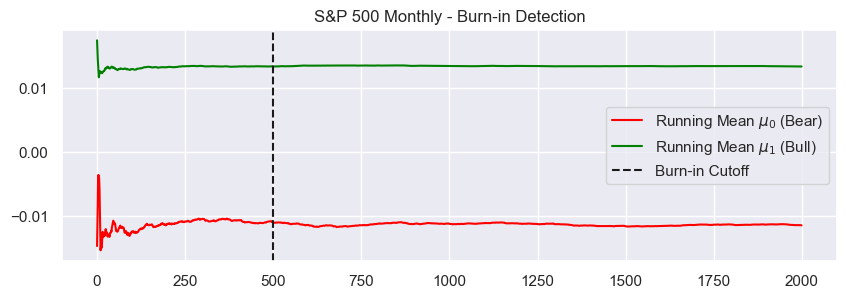

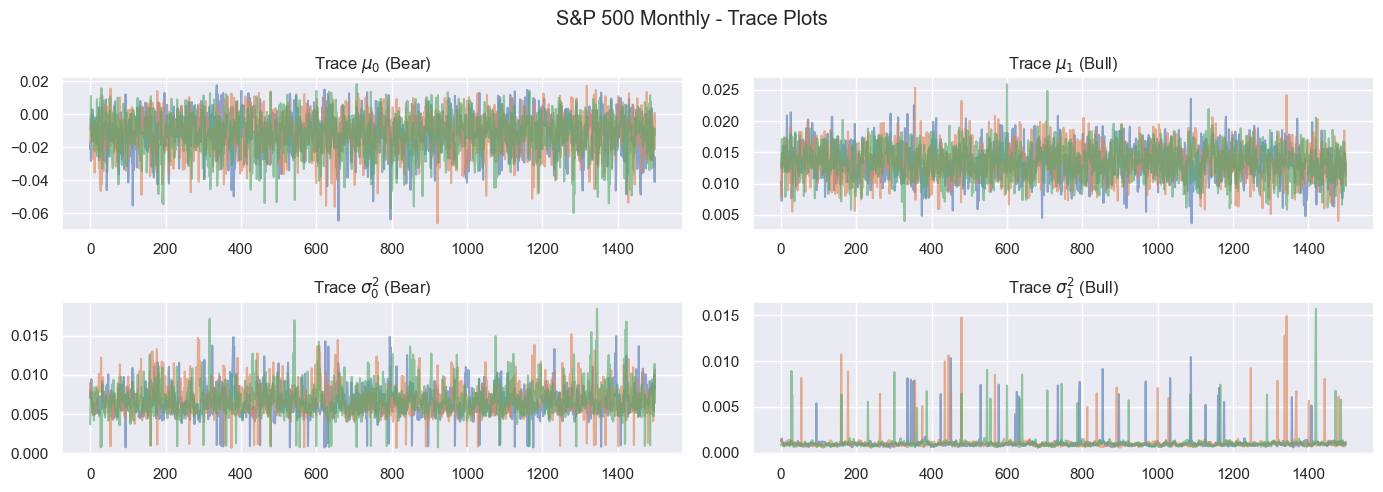

=== S&P 500 Monthly Gelman-Rubin R-hat ===
mu_0: 1.0010
mu_1: 0.9997
sigma2_0: 1.0023
sigma2_1: 0.9999


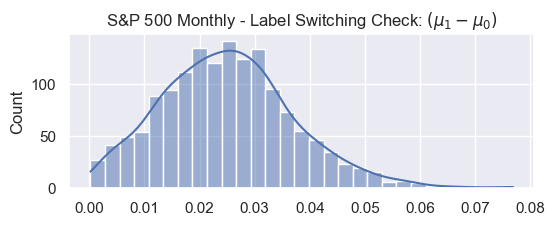

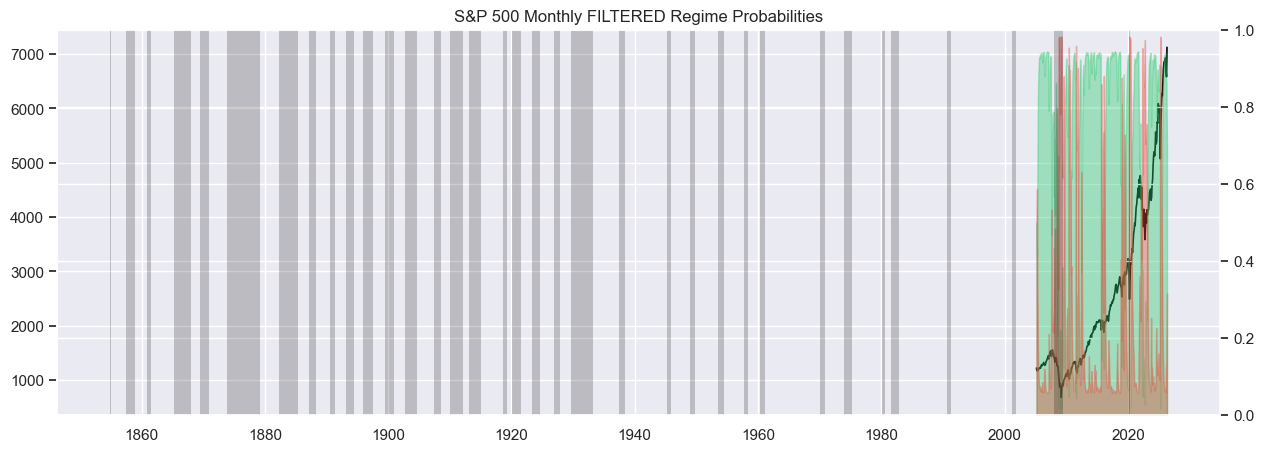

In [4]:
y_sp_m = sp500_m['Log_Return'].values
np.random.seed(42)

sp_chains = []
for i in range(3):
    res, burn = gibbs_msm(y_sp_m, n_iter=2000, burn_in=500, a0=10.0, b0=2.0)
    sp_chains.append(res)

sp_post_burn = run_diagnostics(sp_chains, burn, "S&P 500 Monthly")

# Filtered Regime Probabilities (using Chain 1)
P_filt_avg_sp = np.mean(sp_post_burn[0]['P_filt'], axis=0)
P_bull_sp_m = P_filt_avg_sp[:, 1]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(sp500_m.index, sp500_m['Close'], color='black', lw=1.2, label='S&P 500 (Monthly)')
ax2 = ax1.twinx()
ax2.fill_between(sp500_m.index, 0, P_bull_sp_m, color='#2ecc71', alpha=0.4, label='P(Bull) - Filtered')
ax2.fill_between(sp500_m.index, 0, 1-P_bull_sp_m, color='#e74c3c', alpha=0.4, label='P(Bear) - Filtered')
ax2.set_ylim(0, 1)

mask = recession_df['USREC'] == 1
in_rec, start = False, None
for date, val in mask.items():
    if val and not in_rec:  start, in_rec = date, True
    elif not val and in_rec:
        ax2.axvspan(start, date, color='black', alpha=0.2, lw=0)
        in_rec = False
        
plt.title('S&P 500 Monthly FILTERED Regime Probabilities')
plt.show()


## 3. NIFTY 50 Monthly Analysis
Running 3 chains of MCMC for NIFTY 50 using the `Beta(10, 2)` prior.


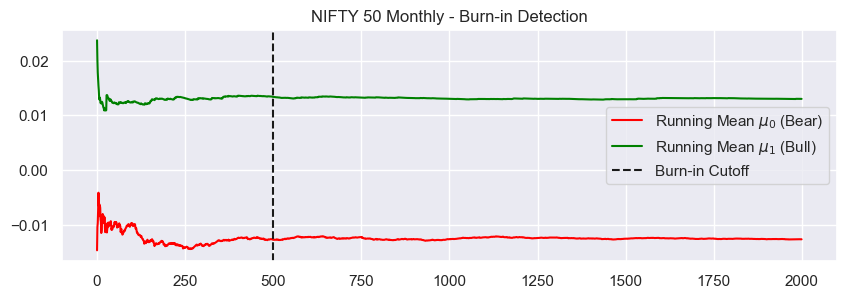

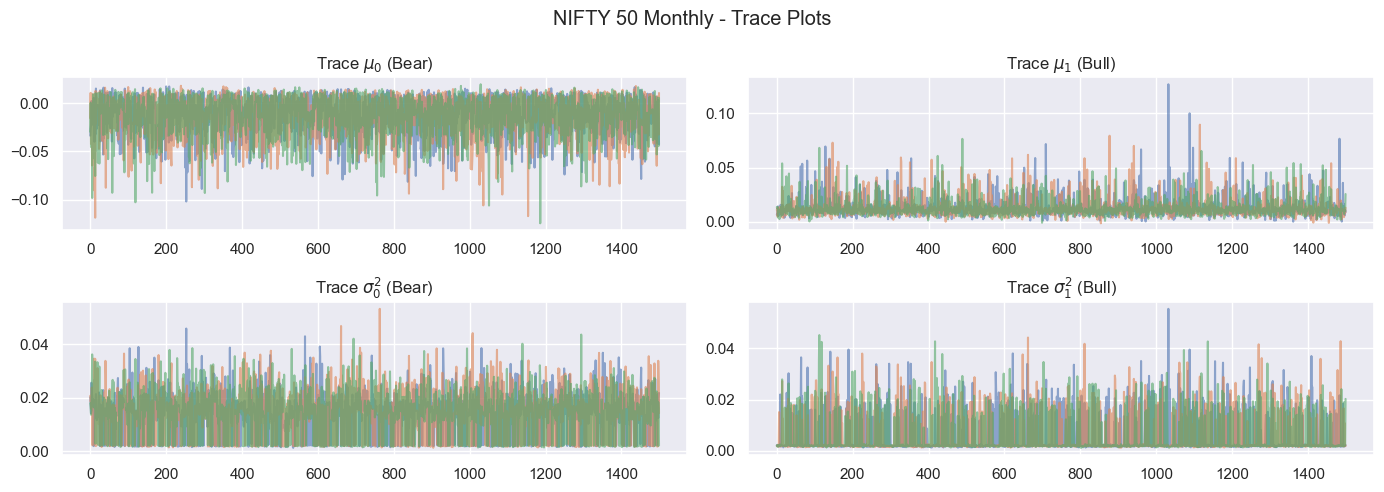

=== NIFTY 50 Monthly Gelman-Rubin R-hat ===
mu_0: 1.0009
mu_1: 0.9998
sigma2_0: 1.0007
sigma2_1: 0.9997


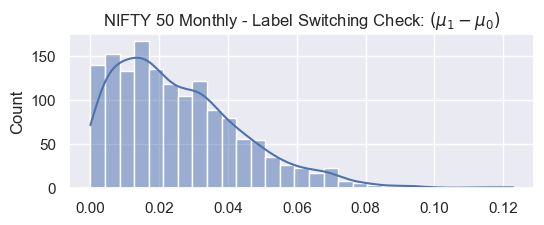

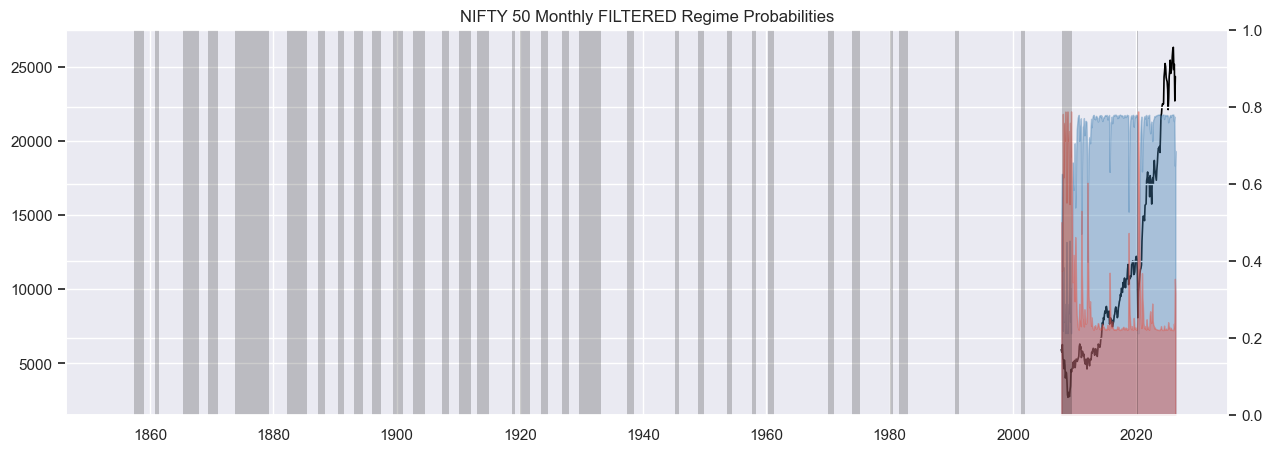

In [5]:
y_nf_m = nifty50_m['Log_Return'].values
np.random.seed(42)

nf_chains = []
for i in range(3):
    res, burn = gibbs_msm(y_nf_m, n_iter=2000, burn_in=500, a0=10.0, b0=2.0)
    nf_chains.append(res)

nf_post_burn = run_diagnostics(nf_chains, burn, "NIFTY 50 Monthly")

# Filtered Regime Probabilities (using Chain 1)
P_filt_avg_nf = np.mean(nf_post_burn[0]['P_filt'], axis=0)
P_bull_nf_m = P_filt_avg_nf[:, 1]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(nifty50_m.index, nifty50_m['Close'], color='black', lw=1.2, label='NIFTY 50 (Monthly)')
ax2 = ax1.twinx()
ax2.fill_between(nifty50_m.index, 0, P_bull_nf_m, color='steelblue', alpha=0.4, label='P(Bull) - Filtered')
ax2.fill_between(nifty50_m.index, 0, 1-P_bull_nf_m, color='#e74c3c', alpha=0.4, label='P(Bear) - Filtered')
ax2.set_ylim(0, 1)

mask = recession_df['USREC'] == 1
in_rec, start = False, None
for date, val in mask.items():
    if val and not in_rec:  start, in_rec = date, True
    elif not val and in_rec:
        ax2.axvspan(start, date, color='black', alpha=0.2, lw=0)
        in_rec = False
        
plt.title('NIFTY 50 Monthly FILTERED Regime Probabilities')
plt.show()


## 4. Structural Distributions (Expected Duration & Ergodic Probs)
We calculate the expected durations (in months) and ergodic probabilities for both markets.


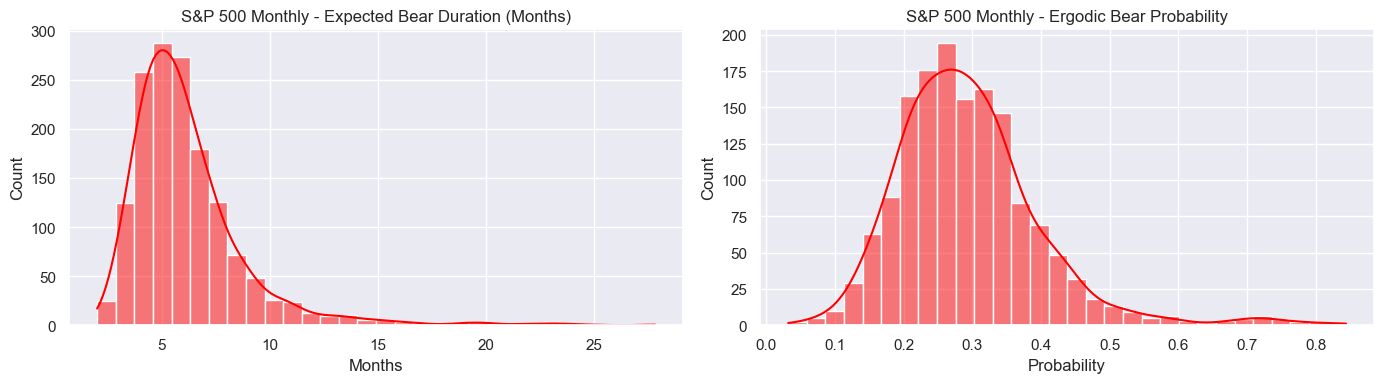

=== S&P 500 Monthly ===
Expected Bear Duration (95% CI): [3.1, 13.4] months
Ergodic Bear Probability (95% CI): [0.134, 0.544]


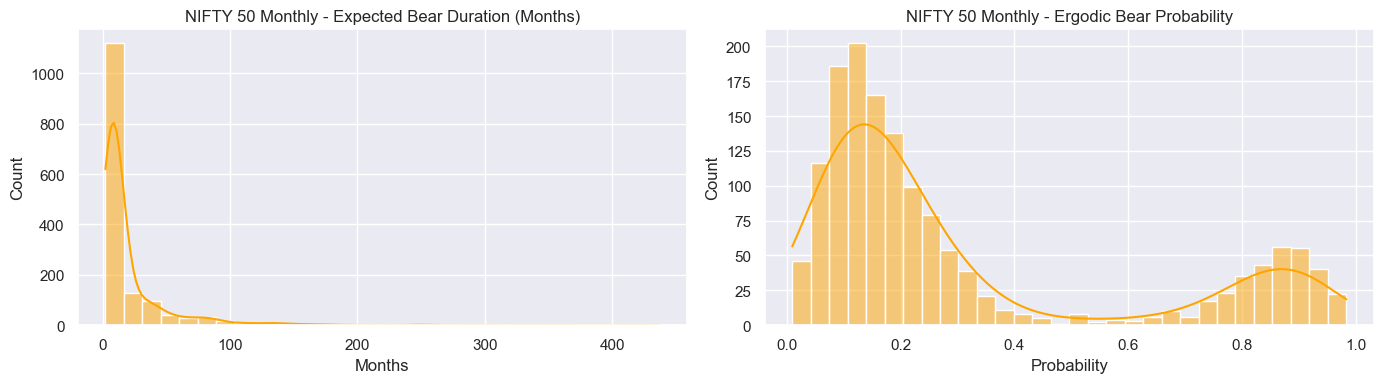

=== NIFTY 50 Monthly ===
Expected Bear Duration (95% CI): [3.6, 111.1] months
Ergodic Bear Probability (95% CI): [0.039, 0.934]


In [6]:
def plot_structure(post_data, title_prefix, color):
    p00 = post_data['p'][:, 0]
    p11 = post_data['p'][:, 1]
    
    ED_bear = 1.0 / (1.0 - p00)
    pi_bear = (1.0 - p11) / (2.0 - p00 - p11)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(ED_bear, bins=30, kde=True, ax=axes[0], color=color)
    axes[0].set_title(f'{title_prefix} - Expected Bear Duration (Months)')
    axes[0].set_xlabel('Months')
    
    sns.histplot(pi_bear, bins=30, kde=True, ax=axes[1], color=color)
    axes[1].set_title(f'{title_prefix} - Ergodic Bear Probability')
    axes[1].set_xlabel('Probability')
    plt.tight_layout()
    plt.show()
    
    print(f"=== {title_prefix} ===")
    print(f"Expected Bear Duration (95% CI): [{np.percentile(ED_bear, 2.5):.1f}, {np.percentile(ED_bear, 97.5):.1f}] months")
    print(f"Ergodic Bear Probability (95% CI): [{np.percentile(pi_bear, 2.5):.3f}, {np.percentile(pi_bear, 97.5):.3f}]")

plot_structure(sp_post_burn[0], "S&P 500 Monthly", "red")
plot_structure(nf_post_burn[0], "NIFTY 50 Monthly", "orange")
